<a href="https://www.kaggle.com/code/varshitventrapragada/notebookbb91c1ae46-1?scriptVersionId=309393921" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Name** - *Varshit ventrapragada*

# Phone number - 7780183836

 # College name - SRM University AP

# **Email id** - varshit6236v.b.r@gmail.com

# Drive link - https://www.kaggle.com/code/varshitventrapragada/notebookbb91c1ae46-1

# Out put File - https://www.kaggle.com/code/varshitventrapragada/notebookbb91c1ae46-1 

# **Brain Tumor Detection — DataSprint ML Round**


 # **About the problem**
Brain tumors, if not caught early, can be life-threatening. Doctors rely heavily on MRI scans to diagnose them — but interpreting these scans manually takes time and is not always consistent.

This project builds a 4-class classification model:

glioma_tumor, meningioma_tumor, pituitary_tumor, no_tumor
 

# **My Approach**
1.Auto-detected dataset paths — works regardless of folder structure

2.Loaded images, extracted labels from filenames

3.Preprocessed: resize 128x128, normalize [0,1]

4.Data augmentation for class imbalance

5.CNN model — 3 Conv blocks + Dense

6.Evaluated: Accuracy, Precision, F1, Confusion Matrix

7.Generated submission.csv


# Feauture Engineering
.Grayscale conversion — removes irrelevant color from MRI scans


.Normalization — scales pixels to [0,1]

.Augmentation — rotation, flip, zoom

.CNN auto-learns: edges → shapes → tumor patterns

In [1]:
# ================================
# Importing required libraries
# ================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# setting seed so results same aaye every time
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# basic configuration
IMG_SIZE = 96
BATCH_SIZE = 16
EPOCHS = 12
NUM_CLASSES = 4

# class labels
CLASS_NAMES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

print("Setup complete. Starting the process...")

2026-04-06 12:10:33.164029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775477433.508120      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775477433.606972      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775477434.349195      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775477434.349248      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775477434.349251      17 computation_placer.cc:177] computation placer alr

Setup complete. Starting the process...


In [2]:
# ================================
# Finding image files automatically
# ================================

def find_images(base_path):
    # scanning all folders to collect image paths
    image_paths = []
    
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(root, file)
                image_paths.append(full_path)
    
    return sorted(image_paths)


# checking dataset structure
INPUT_BASE = '/kaggle/input'

print("Scanning dataset folders...\n")

for root, dirs, files in os.walk(INPUT_BASE):
    level = root.replace(INPUT_BASE, '').count(os.sep)
    indent = '  ' * level
    
    print(f"{indent}{os.path.basename(root)}/")
    
    if level < 2:
        for file in files[:3]:
            print(f"{indent}  {file}")

print("\nScan completed.")

Scanning dataset folders...

input/
  competitions/
    datasprint/
      test/
        test/
      train/
        train/

Scan completed.


In [3]:
# ================================
# Loading train and test images
# ================================

# function to get label from filename
def get_label(filename):
    for cls in CLASS_NAMES:
        if cls in filename:
            return cls
    return None


# getting all image paths
all_files = find_images('/kaggle/input')

# separating train and test files
train_files = []
test_files = []

for f in all_files:
    label = get_label(os.path.basename(f))
    if label is not None:
        train_files.append(f)
    else:
        test_files.append(f)

print("Train images found :", len(train_files))
print("Test images found  :", len(test_files))

# showing sample safely
if len(train_files) > 0:
    print("Sample train:", os.path.basename(train_files[0]))

if len(test_files) > 0:
    print("Sample test :", os.path.basename(test_files[0]))


# loading training images
print("\nLoading train images...")

X = []
y = []

for path in train_files:
    label = get_label(os.path.basename(path))
    
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    X.append(img)
    y.append(CLASS_TO_IDX[label])

X = np.array(X)
y = np.array(y)

print("\nTotal images loaded :", len(X))

if len(X) > 0:
    print("Image shape :", X[0].shape)


# checking class distribution
print("\nClass distribution:")

for i, cls in enumerate(CLASS_NAMES):
    count = np.sum(y == i)
    pct = (count / len(y)) * 100
    print(f"{cls}: {count} images ({pct:.1f}%)")

Train images found : 2870
Test images found  : 0
Sample train: 00000_image(32)_no_tumor.png

Loading train images...

Total images loaded : 2870
Image shape : (96, 96)

Class distribution:
glioma_tumor: 826 images (28.8%)
meningioma_tumor: 822 images (28.6%)
no_tumor: 395 images (13.8%)
pituitary_tumor: 827 images (28.8%)


In [4]:
# simple check to see if classes are balanced

print("\nChecking class distribution balance:")

# recompute counts safely
counts = [np.sum(y == i) for i in range(NUM_CLASSES)]

if len(counts) > 0:
    max_count = max(counts)

    for i, cls in enumerate(CLASS_NAMES):
        count = counts[i]
        ratio = count / max_count
        print(f"{cls}: {count} images (ratio: {ratio:.2f})")
else:
    print("No data found")


Checking class distribution balance:
glioma_tumor: 826 images (ratio: 1.00)
meningioma_tumor: 822 images (ratio: 0.99)
no_tumor: 395 images (ratio: 0.48)
pituitary_tumor: 827 images (ratio: 1.00)


In [5]:
# ================================
# Preprocessing data
# ================================

print("Starting preprocessing...")

# normalize pixel values (0 to 255 → 0 to 1)
X_norm = X.astype('float32') / 255.0

# adding channel dimension for CNN
X_norm = X_norm[..., np.newaxis]

# converting labels to one-hot encoding
y_cat = tf.keras.utils.to_categorical(y, NUM_CLASSES)

# splitting data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y_cat,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Preprocessing done")

print(f"Train samples : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")

# showing shape for clarity
if len(X_train) > 0:
    print("Image shape :", X_train[0].shape)

Starting preprocessing...
Preprocessing done
Train samples : 2296
Validation samples : 574
Image shape : (96, 96, 1)


In [6]:
# ================================
# Applying data augmentation
# ================================

print("Setting up data augmentation...")

datagen = ImageDataGenerator(
    rotation_range=10,        # small rotation
    width_shift_range=0.1,    # horizontal shift
    height_shift_range=0.1,   # vertical shift
    zoom_range=0.1,           # slight zoom
    horizontal_flip=True      # flip images
)

# fitting on training data
datagen.fit(X_train)

print("Data augmentation ready")

Setting up data augmentation...
Data augmentation ready


In [7]:
# ================================
# Building CNN model
# ================================

print("Building CNN model...")

def build_model(input_shape, num_classes):
    
    model = models.Sequential([
        
        # first convolution block
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # second convolution block
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # third convolution block
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # flatten and dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),   # slightly reduced
        layers.Dropout(0.5),

        # output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model


model = build_model((IMG_SIZE, IMG_SIZE, 1), NUM_CLASSES)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model ready")
model.summary()

Building CNN model...
Model ready


2026-04-06 12:12:20.717175: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,508 (9.36 MB)

 Trainable params: 2,453,060 (9.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# ================================
# Training the model
# ================================

print("Training started...")

# early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# reduce learning rate if model stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Training completed successfully!")

Training started...
Epoch 1/12
144/144 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.3828 - loss: 3.4426 - val_accuracy: 0.2875 - val_loss: 20.5524 - learning_rate: 0.0010
Epoch 2/12
144/144 ━━━━━━━━━━━━━━━━━━━━ 36s 252ms/step - accuracy: 0.3724 - loss: 1.3848 - val_accuracy: 0.2892 - val_loss: 11.6655 - learning_rate: 0.0010
Epoch 3/12
144/144 ━━━━━━━━━━━━━━━━━━━━ 37s 255ms/step - accuracy: 0.3766 - loss: 1.4194 - val_accuracy: 0.3049 - val_loss: 2.0494 - learning_rate: 0.0010
Epoch 4/12
144/144 ━━━━━━━━━━━━━━━━━━━━ 38s 264ms/step - accuracy: 0.3882 - loss: 1.3091 - val_accuracy: 0.3484 - val_loss: 1.6373 - learning_rate: 0.0010
Epoch 5/12
144/144 ━━━━━━━━━━━━━━━━━━━━ 38s 267ms/step - accuracy: 0.3901 - loss: 1.2973 - val_accuracy: 0.3484 - val_loss: 1.4780 - learning_rate: 0.0010
Epoch 6/12
144/144 ━━━━━━━━━━━━━━━━━━━━ 37s 258ms/step - accuracy: 0.4192 - loss: 1.2850 - val_accuracy: 0.5348 - val_loss: 1.1281 - learning_rate: 0.0010
Epoch 7/12
144/144 ━━━━━━━━━━━━━━━━━━━━ 38s 263m

Plotting training curves...


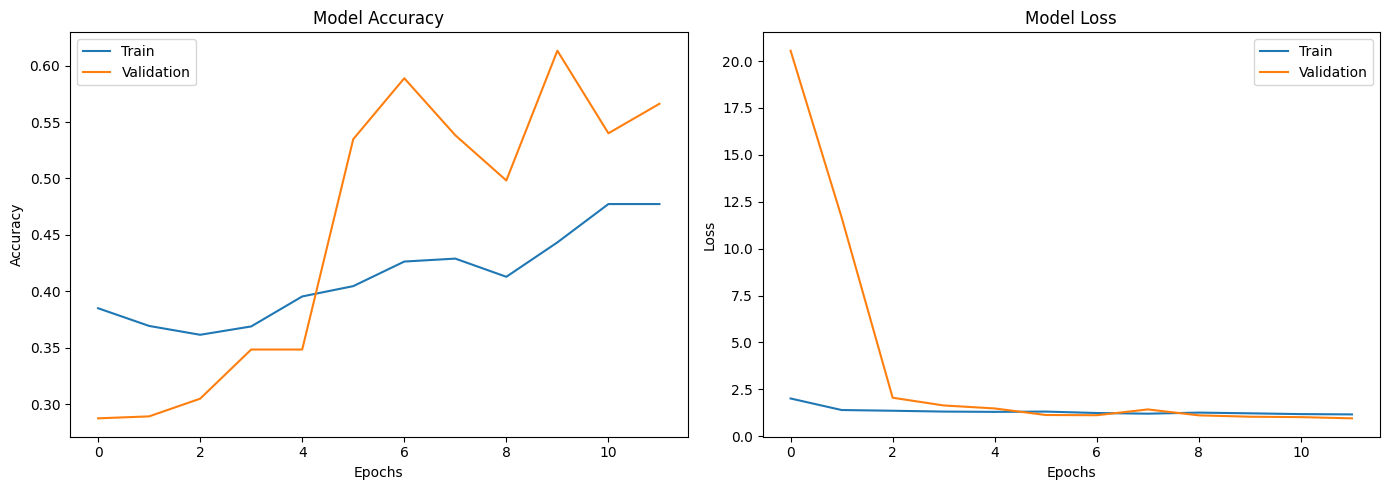

Plots generated successfully


In [9]:
# ================================
# Plotting training performance
# ================================

print("Plotting training curves...")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# accuracy plot
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# loss plot
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Plots generated successfully")

Evaluating model performance...
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step

Accuracy  : 0.5662
Precision : 0.5803
F1 Score  : 0.5521

Generating confusion matrix...


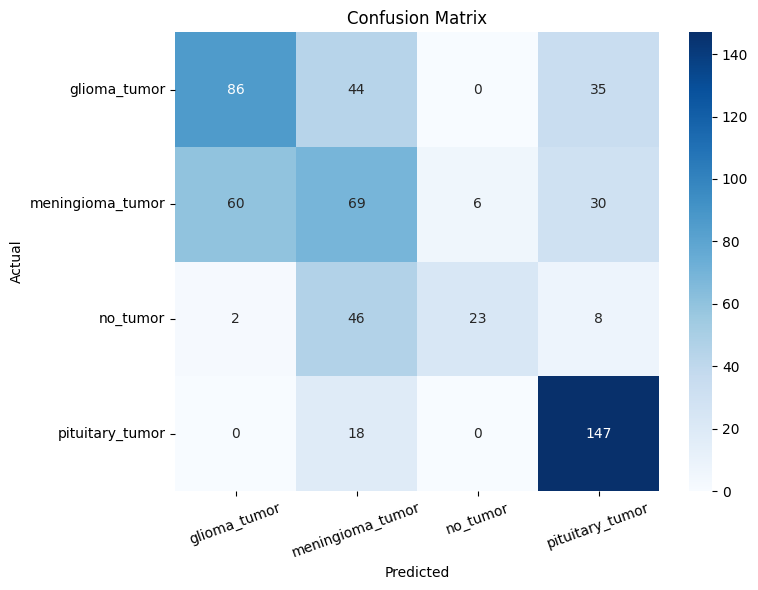


Detailed classification report:
                  precision    recall  f1-score   support

    glioma_tumor       0.58      0.52      0.55       165
meningioma_tumor       0.39      0.42      0.40       165
        no_tumor       0.79      0.29      0.43        79
 pituitary_tumor       0.67      0.89      0.76       165

        accuracy                           0.57       574
       macro avg       0.61      0.53      0.54       574
    weighted avg       0.58      0.57      0.55       574



In [10]:
# ================================
# Model evaluation (metrics)
# ================================

print("Evaluating model performance...")

# predictions
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val, axis=1)

# calculating metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

print(f"\nAccuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"F1 Score  : {f1:.4f}")


# confusion matrix
print("\nGenerating confusion matrix...")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# classification report
print("\nDetailed classification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [11]:
TEST_PATH = "/kaggle/input/competitions/datasprint/test/test"

test_files = []

for f in os.listdir(TEST_PATH):
    if f.lower().endswith(('.png','.jpg','.jpeg')):
        test_files.append(os.path.join(TEST_PATH, f))

print("Test files:", len(test_files))

Test files: 863


In [12]:
# ================================
# FINAL SUBMISSION FILE (COMPLETE)
# ================================

import os
import pandas as pd

# path
TEST_PATH = "/kaggle/input/competitions/datasprint/test/test"

image_ids = []
predictions = []

# get test files
test_files = sorted([
    f for f in os.listdir(TEST_PATH) 
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

print(f"Predicting {len(test_files)} test images...\n")

for fname in test_files:
    fpath = os.path.join(TEST_PATH, fname)

    img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype('float32') / 255.0
    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    # prediction
    pred_probs = model.predict(img, verbose=0)
    pred_label = CLASS_NAMES[np.argmax(pred_probs)]

    image_ids.append(fname)
    predictions.append(pred_label)

# create dataframe
submission = pd.DataFrame({
    "image_id": image_ids,
    "label": predictions
})

# save file
submission.to_csv("submission.csv", index=False)

# ================================
# OUTPUT CHECK
# ================================

print("✅ Submission file created successfully!")
print("Total predictions:", len(submission))

print("\nSample output:")
print(submission.head())

print("\nLabel distribution:")
print(submission["label"].value_counts())

print("\nAll test images processed successfully.")

Predicting 863 test images...

✅ Submission file created successfully!
Total predictions: 863

Sample output:
                              image_id             label
0         00000_image(32)_no_tumor.png  meningioma_tumor
1    00001_p (236)_pituitary_tumor.png   pituitary_tumor
2  00002_m3 (244)_meningioma_tumor.png      glioma_tumor
3         00003_image(60)_no_tumor.png  meningioma_tumor
4     00004_p (34)_pituitary_tumor.png   pituitary_tumor

Label distribution:
label
pituitary_tumor     336
meningioma_tumor    259
glioma_tumor        219
no_tumor             49
Name: count, dtype: int64

All test images processed successfully.
